# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

Text(0.5, 1.0, 'Tardiness (Tardies) of the students by Age')

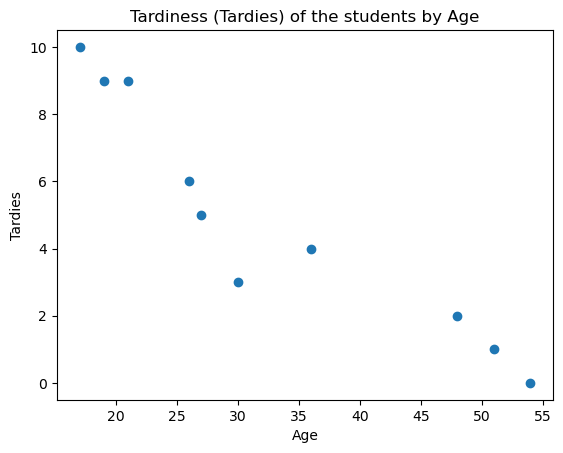

In [4]:
plt.scatter(x = 'Age', y ='Tardies', data = student_data)
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Tardiness (Tardies) of the students by Age')

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

We can see a negative covariance between the two, as the age increases, the value of tardies decreases.

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [ ]:
print("Covariance Table : \n", student_data.cov())
print("\n -------------------------------------------\n")
print("Correlation Table : \n", student_data.corr())

# The main difference between covariance coefficients and correlation coefficients is that the covariance is scale-dependant (values follows the variables values) while the correlation coefficients are normalized between -1 and 1, removing this dependency and enable comparison of extreme values in a clearer way (very high or low numbers).
# The covariance shows negative values between 'Age' and 'Tardies' which indicates the negative relationship between these variables.
# When looking at the correlation table, the high negative value of -0.94 of the Pearson's coefficients confirms the strong negative correlation (close to perfect negative -1 coefficient) between Tardies and Age.

Covariance Table : 
                 Age    Tardies
Age      187.655556 -45.566667
Tardies  -45.566667  12.544444

 -------------------------------------------

Correlation Table : 
               Age   Tardies
Age      1.000000 -0.939163
Tardies -0.939163  1.000000


Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [ ]:
model = smf.ols(formula='Tardies ~ Age', data = student_data).fit()
print(model.summary())

# We use the Ordinary Least Squares method to build the regression model. The outcome variable will be the tardiness or tardies.
# Using this method we find that the R-squared value of 0.88 which shows that the fit explains about 88% of the variance.
# This high value allows us to say that our model fits with good accuracy the data.
# We also find the intercept and slope values to be respectively 12.9 and -0.24. We can then write the regression equation as: y = -0.24x + 12.9
# The small value of P > |t| indicates that the relationship is also statistically significant and not just due by chance.

                            OLS Regression Results                            
Dep. Variable:                Tardies   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     59.81
Date:                Thu, 14 May 2026   Prob (F-statistic):           5.57e-05
Time:                        21:15:47   Log-Likelihood:                -15.622
No. Observations:                  10   AIC:                             35.24
Df Residuals:                       8   BIC:                             35.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.8888      1.111     11.605      0.0

In [43]:
# We can also use the LinearRegression class to compute and fit the OLS model
model = LinearRegression()
model.fit(X= student_data['Age'].values.reshape(-1,1), y = student_data['Tardies'])
print(f"slope is: {model.coef_} \nintercept is: {model.intercept_}")
# We find the same results when using the smf.ols method.

slope is: [-0.24282077] 
intercept is: 12.888803363135771


Plot your regression model on your scatter plot.

Text(0.5, 1.0, 'Tardiness (Tardies) of the students by Age')

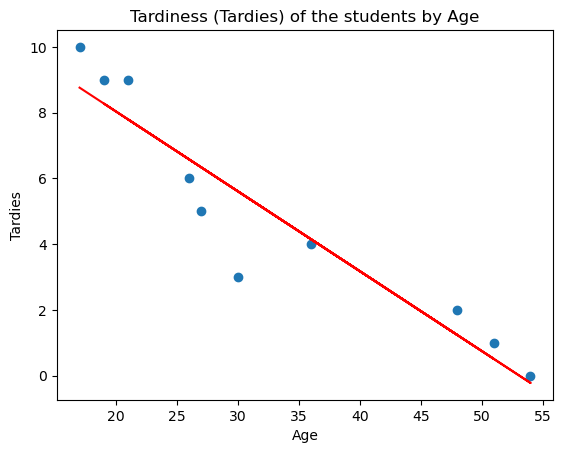

In [44]:
# Your code here.
X = student_data['Age'].values.reshape(-1,1)
y_pred_tardies = model.predict(X)

plt.plot(student_data['Age'], student_data['Tardies'], "o")
plt.plot(X,y_pred_tardies, 'r')
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Tardiness (Tardies) of the students by Age')

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

Our model shows that the relationship between Age and Tardiness of the students can be explained through the following equation: $$ Tardies = -0.24*Age + 12.9 $$

This model exhibit a $r^2$ value of 0.88 validating the accuracy of the model. This model also allows us to confirm the negative covariance and correlation between the two variables. The tardiness decreases with age for the students.

We can say that age is a good predictor in this sample. We cannot conclude that in general age is a good predictor because other factors can impact the results, also the sample size is small which could lead to different outcomes with larger sample sizes.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [35]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

In [36]:
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [37]:
vehicles.columns

Index(['Make', 'Model', 'Year', 'Engine Displacement', 'Cylinders',
       'Transmission', 'Drivetrain', 'Vehicle Class', 'Fuel Type',
       'Fuel Barrels/Year', 'City MPG', 'Highway MPG', 'Combined MPG',
       'CO2 Emission Grams/Mile', 'Fuel Cost/Year'],
      dtype='object')

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

<Axes: >

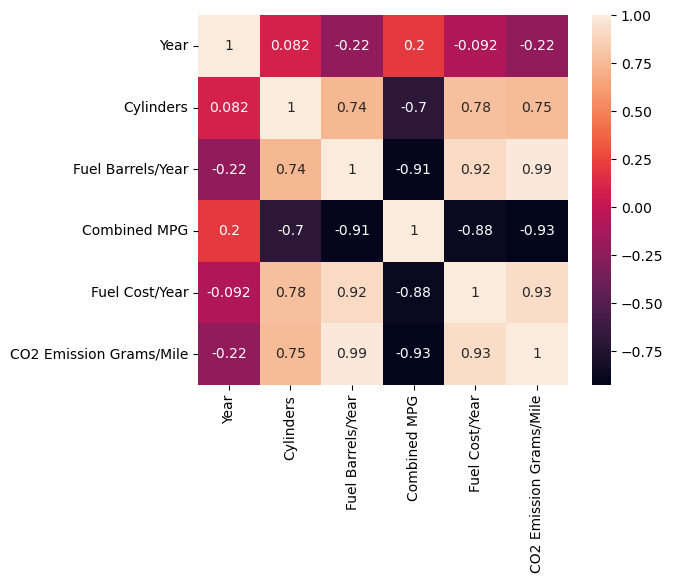

In [58]:
# We select the columns of interest
features = ['Year', 'Cylinders', 'Fuel Barrels/Year','Combined MPG','Fuel Cost/Year', 'CO2 Emission Grams/Mile']

# We compute the correlation coefficients between all columns
corrmat = vehicles[features].corr()

# We plot the heatmap
sns.heatmap(corrmat, square=True, annot=True)

# When looking at the 'CO2 Emission Grams/Mile' feature, we can see that 'Year' has the smallest (in absolute value) coefficient, showing that it has the lowest correlation with the CO2 Emission feature.
# On the other hand 'Cylinders', 'Fuel Cost/Year' and 'Fuel Barrels/Year' have high positive coefficents showing a strong positive correlation. We notice that the Cylinder coefficient is at 0.75 while the other 2 are at 0.99 and 0.93 which shows that the correlation between CO2 Emission and Cylinder is weaker than with the other 2 features.
# Finally the high negative coefficient found between CO2 Emission and 'Combined MPG' shows a strong negative correlation between these features.
# We can conclude that the variable with the most influence on the CO2 Emissions is 'Fuel Barrels/Year' with the highest coeficient of 0.99 while the variable with the least amount of helpful information is 'Cylinders' with lowest coefficient (in absolute value) of -0.22.

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [73]:
# With smf.ols
data = vehicles[['Fuel Barrels/Year','CO2 Emission Grams/Mile']].rename(
    columns={
        'Fuel Barrels/Year': 'Fuel_Barrels_Year',
        'CO2 Emission Grams/Mile': 'CO2_Emission_Grams_Mile'
    }
)

model = smf.ols(formula='CO2_Emission_Grams_Mile ~ Fuel_Barrels_Year', data = data).fit()

# With LinearRegression class
X_var = vehicles['Fuel Barrels/Year'].values.reshape(-1,1)
y_var = vehicles['CO2 Emission Grams/Mile']

model2 = LinearRegression()
model2.fit(X_var,y_var)

# We use the Ordinary Least Square Method to build the regression model.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [ ]:
# Your code here.
print(model.summary())
print('\n')
print("LinearRegression fit:")
print(f"slope is: {model2.coef_} \nintercept is: {model2.intercept_}\nR-square: {model2.score(X_var,y_var)}")

# Using both methods we find the same results.
# The relationship between 'CO2 Emission Grams/Mile' and 'Fuel Barrels/Year' showed strong positive correlation from the heatmap. This relationship is confirmed here with a high R-square value of 0.97 meaning that 97% of the variance is explained with this model.
# The intercept and slope allow us to use the following equation to describe the relationship:
# 'CO2 Emission Grams/Mile' = 26.3 * 'Fuel Barrels/Year' + 12.5
# The positive slope confirms the positive covariance while the P > |t| value of 0 confirms that the results are statistically significant.

# We can conclude that the model found highlights the strong positive correlation between the two variables with a high confidence in our result (high R-square). We can conclude that 'Fuel Barrels/Year' is a good predictor of 'CO2 Emission Grams/Mile' in this sample.

                               OLS Regression Results                              
Dep. Variable:     CO2_Emission_Grams_Mile   R-squared:                       0.973
Model:                                 OLS   Adj. R-squared:                  0.973
Method:                      Least Squares   F-statistic:                 1.275e+06
Date:                     Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                             22:14:43   Log-Likelihood:            -1.5821e+05
No. Observations:                    35952   AIC:                         3.164e+05
Df Residuals:                        35950   BIC:                         3.164e+05
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [3]:
# Your code here.
data = pd.DataFrame({'invited_people':[1,3,4,6,8,9,11,14],
                     'people_attended': [1,2,4,4,5,7,8,13]})

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

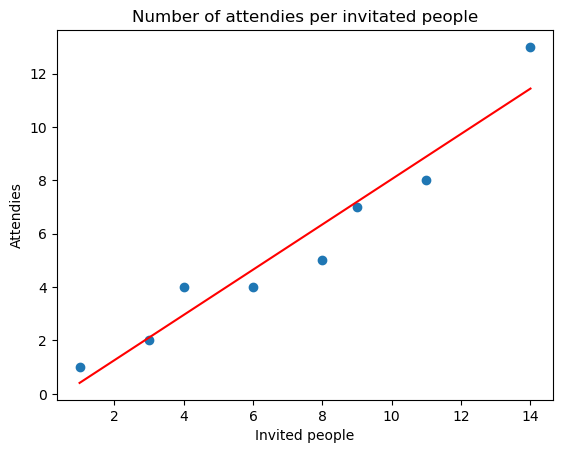

                            OLS Regression Results                            
Dep. Variable:        people_attended   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     81.81
Date:                Sat, 16 May 2026   Prob (F-statistic):           0.000102
Time:                        10:35:32   Log-Likelihood:                -10.800
No. Observations:                   8   AIC:                             25.60
Df Residuals:                       6   BIC:                             25.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.4394      0.759     -0.

In [4]:
# Your code here.
model = smf.ols(formula='people_attended ~ invited_people', data = data).fit()
y_pred = model.predict(data['invited_people'])

plt.plot(data['invited_people'], data['people_attended'], "o")
plt.plot(data['invited_people'],y_pred, 'r')
plt.xlabel('Invited people')
plt.ylabel('Attendies')
plt.title('Number of attendies per invitated people')
plt.show()
print(model.summary())

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

Our model shows that the relationship between then umber of invited people and the number of attendies can be modeled through the following equation: $$ Attendies = 0.85*Invited - 0.4 $$

Although the negative intercept(negative number of attendies when nobody is invited), this model exhibit a $r^2$ value of 0.93 validating the accuracy of the model. This model also allows us to confirm the positive relationship between the two variables. The number of attendies increases with the number of invited people.

We can say that then umber of invited people is a good predictor in this sample. The sample size begin small it is hard to conclude on much more. 

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

<Axes: >

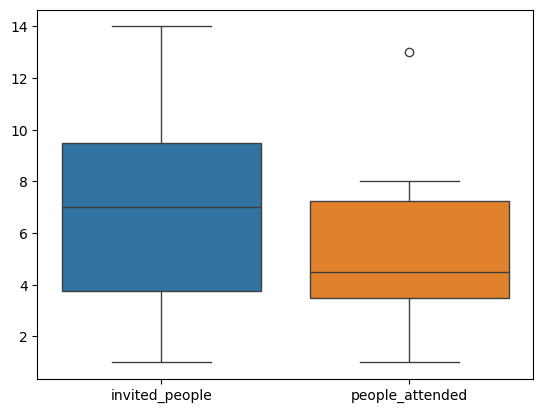

In [5]:
# Your response here.
sns.boxplot(data)
# We can see that there is an outlier which is the value 13 in the people_attended list.

In [6]:
data.tail(1)

,invited_people,people_attended
7,14,13


In [7]:
# Remove the outlier, or the last value of the dataframe
data_cleaned = data[:-1]
print(data_cleaned)

   invited_people  people_attended
0               1                1
1               3                2
2               4                4
3               6                4
4               8                5
5               9                7
6              11                8


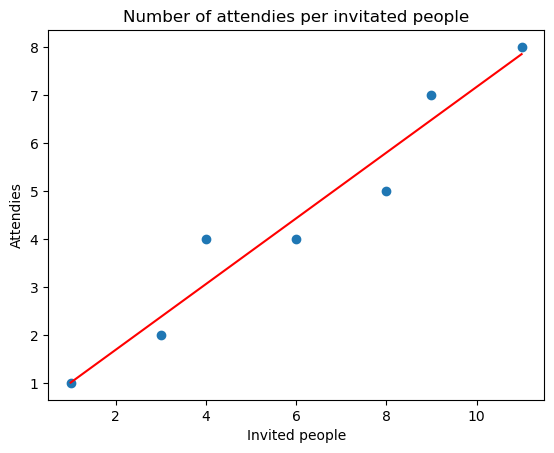

                            OLS Regression Results                            
Dep. Variable:        people_attended   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     83.31
Date:                Sat, 16 May 2026   Prob (F-statistic):           0.000264
Time:                        10:35:40   Log-Likelihood:                -5.7771
No. Observations:                   7   AIC:                             15.55
Df Residuals:                       5   BIC:                             15.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3233      0.513      0.

c:\Users\vince\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
# Repeating the lpoting and fiting for the dataframe without the outlier
model2 = smf.ols(formula='people_attended ~ invited_people', data = data_cleaned).fit()
y_pred2 = model2.predict(data_cleaned['invited_people'])

plt.plot(data_cleaned['invited_people'], data_cleaned['people_attended'], "o")
plt.plot(data_cleaned['invited_people'],y_pred2, 'r')
plt.xlabel('Invited people')
plt.ylabel('Attendies')
plt.title('Number of attendies per invitated people')
plt.show()
print(model2.summary())

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

The removal of the outlier affected the model, both coefficients (intercept and slope) have now a value of respectively 0.32 and 0.68. The $r^2$ value also increased to 0.94 (was 0.93 previously) which translates a better confidence in the new model after removal of the outlier.

The new model gives us the following equation: $$ Attendies = 0.68*Invited + 0.32 $$

We can note the change in sign for the intercept (makes more sense that someone shows up even when 0 invites were sent than negative people show up when no invites were sent). In our case here, removing the problematic point change the coefficients which resulted in an increased $r^2$ value. This allows us to be more confident in this new model.

We can conclude that the presence of the outlier influences the end result of the fitting, in terms of coefficients, confidence index ($r^2$). Therefore the decision to ignore them (or not) should be carefully investigated.